In [1]:
import pandas as pd
import numpy as np
import pickle as pk
import os, sys
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../../"), os.pardir)))
from customFunctions.utils import binary_auROC

In [2]:
gridsearch = pk.load(open("gridsearch.pk", "rb"))
gridsearch

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=24, random_state=420),
             error_score='raise',
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', '...
                                                                       scoring_function=<function roc_auc_score at 0x7dd3f9f00220>,
                                                                       verbose=99))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7dd3f87cd3a0>, verbose=99)

In [3]:
cv_results = pd.DataFrame(gridsearch.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False).loc[:, cv_results.columns.str.match("param_") | (cv_results.columns=="mean_test_score")]
cv_results

,param_channels_correlation_filter__corr_threshold,param_channels_pca__n_components,param_input_selection__channel_selection__alpha,param_input_selection__feature_selection__threshold,mean_test_score
168,0.40,3,0.01,0.01,0.892045
172,0.40,3,0.05,0.01,0.891098
144,0.40,1,0.01,0.01,0.889205
180,0.40,5,0.01,0.01,0.888258
68,0.25,2,0.10,0.01,0.886364
...,...,...,...,...,...
66,0.25,2,0.05,0.03,0.835183
142,0.30,5,0.10,0.03,0.834258
91,0.25,5,0.05,0.05,0.834148
42,0.20,5,0.05,0.03,0.831417


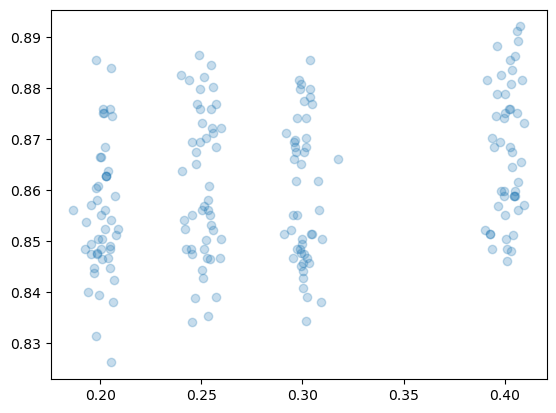

In [4]:
plt.scatter(
    cv_results.param_channels_correlation_filter__corr_threshold+np.random.normal(0, .005, len(cv_results)),
    cv_results.mean_test_score,
    alpha=.25
)

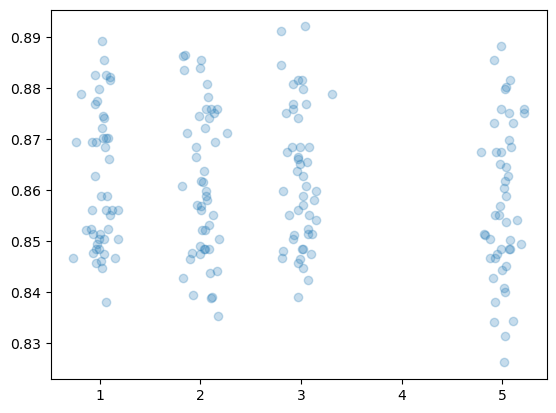

In [5]:
plt.scatter(
    cv_results.param_channels_pca__n_components+np.random.normal(0, .1, len(cv_results)),
    cv_results.mean_test_score,
    alpha=.25
)

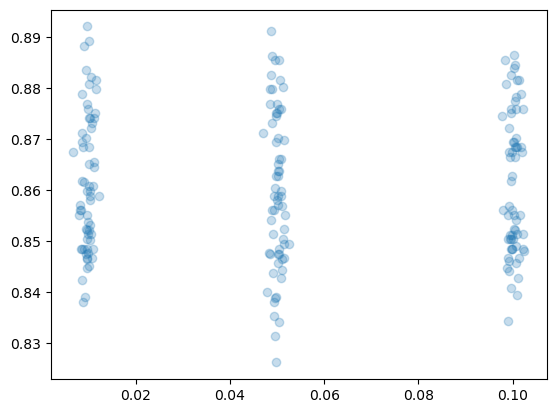

In [6]:
plt.scatter(
    cv_results.param_input_selection__channel_selection__alpha+np.random.normal(0, .001, len(cv_results)),
    cv_results.mean_test_score,
    alpha=.25
)

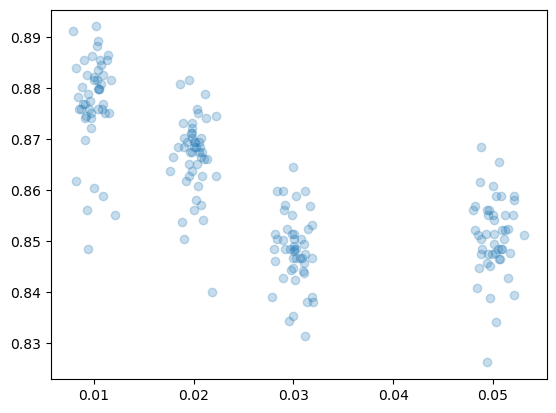

In [7]:
plt.scatter(
    cv_results.param_input_selection__feature_selection__threshold+np.random.normal(0, .001, len(cv_results)),
    cv_results.mean_test_score,
    alpha=.25
)

In [8]:
actual_model = pk.load(open("../../checkpoints/candidate_models/model_rf.pk", "rb"))
actual_model

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7dd3f0db2490>,
                                                scoring_function=<function roc_auc_score at 0x7dd3f9f00220>,
                                                verbose=99))])

In [9]:
actual_model.get_params()["channels_correlation_filter__corr_threshold"]

0.25

In [10]:
(
    actual_model.get_params()["channels_correlation_filter__corr_threshold"],
    actual_model.get_params()["channels_pca__n_components"],
    actual_model.get_params()["input_selection__channel_selection__alpha"],
    actual_model.get_params()["input_selection__feature_selection__threshold"]
)

(0.25, 5, 0.01, 0.01)

In [11]:
actual_params_auc = cv_results\
    .query("(param_channels_correlation_filter__corr_threshold==0.25)&(param_channels_pca__n_components==5)&(param_input_selection__channel_selection__alpha==0.01)&(param_input_selection__feature_selection__threshold==0.01)")\
        .mean_test_score.values[0]
actual_params_auc

np.float64(0.8759249471458773)

In [12]:
(cv_results.mean_test_score > actual_params_auc).mean()

np.float64(0.1875)

In [13]:
cv_results[(cv_results.mean_test_score > actual_params_auc)]

,param_channels_correlation_filter__corr_threshold,param_channels_pca__n_components,param_input_selection__channel_selection__alpha,param_input_selection__feature_selection__threshold,mean_test_score
168,0.40,3,0.01,0.01,0.892045
172,0.40,3,0.05,0.01,0.891098
144,0.40,1,0.01,0.01,0.889205
180,0.40,5,0.01,0.01,0.888258
68,0.25,2,0.10,0.01,0.886364
160,0.40,2,0.05,0.01,0.886342
8,0.20,1,0.10,0.01,0.885417
184,0.40,5,0.05,0.01,0.885417
112,0.30,2,0.05,0.01,0.885395
80,0.25,3,0.10,0.01,0.884470


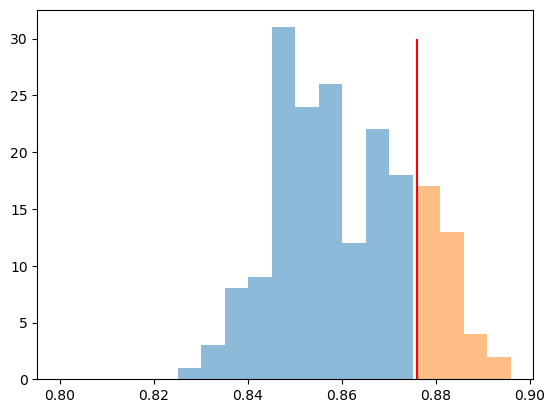

In [19]:
plt.hist(cv_results.loc[(cv_results.mean_test_score < actual_params_auc), "mean_test_score"], bins=np.arange(.8,actual_params_auc,.005), alpha=.5)
plt.hist(cv_results.loc[(cv_results.mean_test_score > actual_params_auc), "mean_test_score"], bins=np.arange(actual_params_auc,.9,.005), alpha=.5)
plt.vlines(actual_params_auc, 0, 30, colors="red")

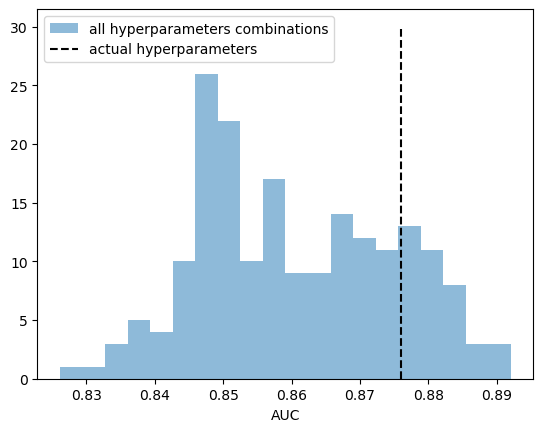

In [32]:
plt.hist(cv_results.mean_test_score, bins=20, alpha=.5, label="all hyperparameters combinations")
plt.plot([actual_params_auc, actual_params_auc], [0, 30], color="k", ls="--", label="actual hyperparameters")
plt.xlabel("AUC")
plt.legend()
plt.show()

In [36]:
tapogee_model = pk.load(open("../../../tAPOGEE/checkpoints/candidate_models/model_svc.pk", "rb"))
tapogee_model

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7f938ac94180>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7f938956d300>, verbose=2)